# 5. Distribución geográfica

En la segunda entrega se observó una asociación fuerte entre `longitude` y la clase de aptitud, probablemente ligada a la composición geográfica del dataset. Este capítulo la examina.

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from utils import *

set_style()
np.random.seed(SEED)
pd.set_option("display.max_columns", 40)
df = load_data()
import plotly.express as px
import plotly.io as pio
pio.renderers.default = "notebook_connected" 

In [2]:
mapa = df.sort_values(TARGET, ascending=False)  # Baja se dibuja encima
fig = px.scatter_geo(
    mapa, lat="latitude", lon="longitude", color=TARGET,
    color_discrete_map=CLASS_COLORS, category_orders={TARGET: CLASS_ORDER},
    hover_name="plant_name", hover_data={"country": True, "latitude": ":.2f",
                                         "longitude": ":.2f", TARGET: True},
    projection="natural earth", opacity=0.6,
    title="Plantas solares por clase de aptitud",
)
fig.update_traces(marker=dict(size=3.5, line=dict(width=0)))
fig.update_geos(showcountries=True, countrycolor="#c3c2b7", showland=True,
                landcolor="#f0efec", oceancolor=SURFACE, showocean=True,
                coastlinecolor="#c3c2b7")
fig.update_layout(height=520, margin=dict(l=0, r=0, t=50, b=0),
                  paper_bgcolor=SURFACE, legend_title_text="Aptitud")
fig.show()

## 5.1 Países con más plantas

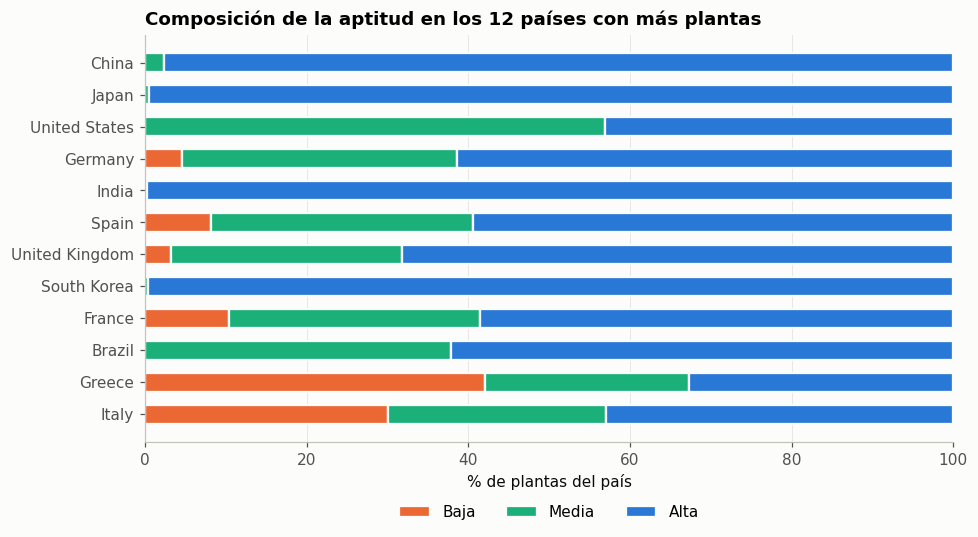

,plantas,Baja,Media,Alta
country,,,,
China,11518,0.0,2.4,97.6
Japan,8598,0.0,0.6,99.4
United States,7224,0.0,56.9,43.0
Germany,7108,4.6,34.0,61.4
India,2907,0.0,0.2,99.8
Spain,2523,8.2,32.4,59.4
United Kingdom,2282,3.2,28.7,68.1
South Korea,2024,0.0,0.4,99.6
France,1449,10.4,31.0,58.6


In [3]:
top = df["country"].value_counts().head(12).index
tabla = (pd.crosstab(df["country"], df[TARGET], normalize="index")
           .loc[top, CLASS_ORDER] * 100)

fig, ax = plt.subplots(figsize=(9, 5))
left = np.zeros(len(top))
for c in CLASS_ORDER:
    ax.barh(top[::-1], tabla[c].values[::-1], left=left[::-1], height=0.6,
            color=CLASS_COLORS[c], label=c, edgecolor=SURFACE, linewidth=1.5)
    left += tabla[c].values
ax.set_xlabel("% de plantas del país")
ax.set_xlim(0, 100)
ax.set_title("Composición de la aptitud en los 12 países con más plantas")
ax.legend(ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.12))
ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

conteo = df["country"].value_counts().head(12).rename("plantas")
pd.concat([conteo, tabla.round(1)], axis=1)

```{important}
La clase depende del país:
- **China, Japón, India y Corea del Sur** la mayoría son Alta.
- **Estados Unidos** con mayoría Media (56.9 %).
- **La clase Baja se concentra en Europa.** Aparece en 79 países, pero Grecia, Alemania, España, Italia y Francia reúnen el 70.3 % de esas plantas.

```